# Guía de Ejercicios 1 — Inteligencia Artificial

## Modelos gráficos probabilísticos con PyMC

Sergio Hernández — `shernandez@ucm.cl` — Universidad Católica del Maule

---

En esta guía trabajaremos con **redes bayesianas**: representación de la
incertidumbre mediante grafos dirigidos acíclicos, independencia condicional e
inferencia diagnóstica.

La guía original usa `pgmpy`, que manipula tablas de probabilidad conjunta.
Aquí usamos **PyMC**, que es una biblioteca de *programación probabilística*:
se declara un **modelo generativo** y todas las probabilidades se estiman
**simulando** casos a partir de él.

| `pgmpy` | PyMC |
|---|---|
| `JointProbabilityDistribution([...])` | `pm.Categorical` sobre los estados conjuntos |
| `d.marginal_distribution(['A'])` | frecuencia relativa en la muestra |
| `d.check_independence(['A'],['B'])` | `independencia_mc(muestra, 'A', 'B')` |
| `BayesianModel([('A','C'), ...])` | `pm.Model` con `pm.Bernoulli` anidadas |
| `model.fit(datos)` | `pm.sample` con priors Beta sobre las CPT |
| `model.is_active_trail('A','B')` | `camino_activo(aristas, 'A', 'B')` |

### El método: simular y contar

Un modelo generativo permite fabricar casos. Para estimar $P(A, B)$ se simulan
cien mil pacientes, se cuenta en qué fracción ocurren ambos eventos, y esa
fracción **es** la estimación. Para condicionar en evidencia, se descartan los
casos que no la cumplen y se cuenta sobre el resto.

La ventaja: es el mismo procedimiento para tres variables o para tres mil, y no
requiere fórmulas nuevas. El costo: toda estimación trae **error de muestreo**,
y hay que saber cuánto.

Por eso, en cada sección compararemos la estimación con el valor **teórico**
calculado a mano. Esa comparación es el hilo conductor de toda la guía.

### Contenidos

1. Repaso de probabilidad — **Ejercicios 1 y 2**
2. Independencia condicional en grafos — **Ejercicios 3, 4 y 5**
3. Red Bayesiana *Asia* — **Ejercicios 6, 7 y 8**

Las celdas marcadas con `# TODO` son las que hay que completar. Cada ejercicio
termina con una verificación automática que imprime `OK` o `REVISAR`.

In [2]:
# Instalación (descomentar la primera vez)
# !pip install pymc networkx pandas matplotlib

import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
import networkx as nx

SEMILLA = 42
print("PyMC", pm.__version__)

PyMC 6.3.1


---
## 0. Caja de herramientas

Cuatro funciones bastan para toda la guía: simular, estimar, comparar contra la
teoría y chequear independencia.


> Ejecute la celda y siga adelante; no es necesario leerla en detalle la primera
> vez.

In [15]:
def muestrear(modelo, n=50_000, semilla=SEMILLA):
    # Simula n casos del modelo generativo (muestreo directo, sin MCMC).
    with modelo:
        previa = pm.sample_prior_predictive(draws=n, random_seed=semilla)
    nombres = ([v.name for v in modelo.free_RVs]
               + [d.name for d in modelo.deterministics])
    return pd.DataFrame({v: previa.prior[v].values.reshape(-1) for v in nombres}, dtype=np.bool)


def _mascara(df, condicion):
    m = pd.Series(True, index=df.index)
    for var, val in (condicion or {}).items():
        m &= df[var] == val
    return m


def p(df, evento, dado=None):
    # Estimacion Monte Carlo de P(evento | dado).
    # Devuelve (estimacion, error_estandar, n_casos_utilizados).
    base = _mascara(df, dado)
    n = int(base.sum())
    if n == 0:
        return np.nan, np.nan, 0
    est = float((base & _mascara(df, evento)).sum()) / n
    # Piso de varianza 1/n: si no ocurre ningun caso la varianza binomial es
    # cero y el error estandar quedaria nulo, lo que hace explotar cualquier
    # cociente. El piso es la correccion de continuidad habitual.
    se = np.sqrt(max(est * (1 - est), 1.0 / n) / n)
    return est, se, n


def comparar(nombre, teorico, estimacion, umbral=4.0):
    # Contrasta un valor teorico con su estimacion Monte Carlo.
    # El criterio es la distancia en errores estandar, no la diferencia bruta:
    # con n grande se exige mas precision que con n chico.
    est, se, n = estimacion
    z = abs(est - teorico) / se if se and se > 0 else np.inf
    marca = "OK      " if z < umbral else "REVISAR "
    print(f"[{marca}] {nombre:<26s} teoria {teorico:7.4f}   "
          f"MC {est:7.4f} +/- {2 * se:.4f}   n={n:>6d}   z={min(z, 999):5.1f}")
    return z < umbral


def independencia_mc(df, X, Y, Z=(), umbral=4.0, n_min=200):
    # Contrasta P(x,y|z) = P(x|z)P(y|z) en la muestra.
    # Devuelve (compatible_con_independencia, maxima_discrepancia_estandarizada).
    # La discrepancia se mide en errores estandar: una diferencia real pero mas
    # pequena que el ruido de muestreo NO se puede detectar con esta muestra.
    X = [X] if isinstance(X, str) else list(X)
    Y = [Y] if isinstance(Y, str) else list(Y)
    Z = [Z] if isinstance(Z, str) else list(Z)
    vals = {v: sorted(df[v].unique()) for v in X + Y + Z}
    z_max = 0.0
    for zc in (itertools.product(*[vals[v] for v in Z]) if Z else [()]):
        ev = dict(zip(Z, zc))
        if int(_mascara(df, ev).sum()) < n_min:
            continue
        for xc in itertools.product(*[vals[v] for v in X]):
            ex = dict(zip(X, xc))
            px = p(df, ex, ev)[0]
            for yc in itertools.product(*[vals[v] for v in Y]):
                ey = dict(zip(Y, yc))
                py = p(df, ey, ev)[0]
                pxy, se, _ = p(df, {**ex, **ey}, ev)
                if se and se > 0:
                    z_max = max(z_max, abs(pxy - px * py) / se)
    return (z_max < umbral), min(z_max, 999.0)


def tabla_2x2(df, A="A", B="B"):
    # Tabla 2x2 con marginales, en el formato del enunciado
    lineas = [f"{'':4s} {B:>8s} {B + chr(39):>8s} {'Marginal':>9s}"]
    for etiqueta, a in [(f"{A} ", 1), (f"{A}'", 0)]:
        pb = p(df, {A: a, B: 1})[0]
        pnb = p(df, {A: a, B: 0})[0]
        lineas.append(f"{etiqueta:4s} {pb:8.4f} {pnb:8.4f} {pb + pnb:9.4f}")
    cb = p(df, {B: 1})[0]
    cnb = p(df, {B: 0})[0]
    lineas.append(f"{'Marg':4s} {cb:8.4f} {cnb:8.4f} {cb + cnb:9.4f}")
    return "\n".join(lineas)


def d_separado(aristas, X, Y, Z=()):
    # Criterio GRAFICO (Bayes-Ball). No depende de los numeros de las CPT.
    g = nx.DiGraph(aristas)
    conv = lambda s: {s} if isinstance(s, str) else set(s)
    return nx.is_d_separator(g, conv(X), conv(Y), conv(Z))


def camino_activo(aristas, X, Y, Z=()):
    # Equivalente a BayesianModel.is_active_trail de pgmpy
    return not d_separado(aristas, X, Y, Z)


def cpt(tabla):
    # Tabla de probabilidad condicional indexable por los valores de los padres
    return pt.as_tensor(np.asarray(tabla, dtype="float64"))


def check(nombre, condicion, pista=""):
    print(f"[{'OK      ' if condicion else 'REVISAR '}] {nombre}"
          + (f"   -> {pista}" if (not condicion and pista) else ""))
    return bool(condicion)


print("Herramientas cargadas.")

Herramientas cargadas.


---
# 1. Repaso de probabilidad

**Convención de índices** (la misma de `pgmpy` y del enunciado): el estado `1`
significa que el evento **ocurre** y el estado `0` que **no ocurre**. Es decir
`A_1` = $A$ y `A_0` = $A'$.

Hay dos formas de declarar $P(A,B)$ en PyMC, y conviene tener ambas a mano:

In [5]:
def modelo_conjunto(p_joint):
    # Forma 1: la conjunta explicita, al estilo de pgmpy.
    # El estado k de la Categorical codifica el par (A,B) mediante k = 2*A + B,
    # de modo que p_joint sigue el orden [P(A0,B0), P(A0,B1), P(A1,B0), P(A1,B1)].
    with pm.Model() as modelo:
        AB = pm.Categorical("AB", p=np.asarray(p_joint))
        pm.Deterministic("A", AB // 2)
        pm.Deterministic("B", AB % 2)
    return modelo


def modelo_factorizado(p_A, p_B_dado_A, p_B_dado_noA):
    # Forma 2: P(A,B) = P(A) P(B|A), que es como se declara una red bayesiana.
    with pm.Model() as modelo:
        A = pm.Bernoulli("A", p_A)
        pm.Bernoulli("B", pt.switch(pt.eq(A, 1), p_B_dado_A, p_B_dado_noA))
    return modelo

In [6]:
np.__version__

'2.4.6'

## 1.1 Eventos mutuamente excluyentes

Dos eventos son mutuamente excluyentes cuando $P(A,B) = 0$: no pueden ocurrir
al mismo tiempo. Con $P(A) = 0.2$ y $P(B) = 0.7$:

| | $B$ | $B'$ | Marginal |
|---|---|---|---|
| $A$ | 0.00 | 0.20 | 0.20 |
| $A'$ | 0.70 | 0.10 | 0.80 |
| Marginal | 0.70 | 0.30 | 1.00 |

Simulamos 50 000 casos y reconstruimos esa tabla contando.

In [27]:
# Orden pgmpy: [P(A0B0), P(A0B1), P(A1B0), P(A1B1)] = [0.1, 0.7, 0.2, 0.0]
mc_excl = muestrear(modelo_conjunto([0.10, 0.70, 0.20, 0.00]))

print("Tabla estimada por muestreo:")
print(tabla_2x2(mc_excl))

print("\nContraste con los valores del enunciado:")
comparar("P(A)",    0.20, p(mc_excl, {"A": True}))
comparar("P(B)",    0.70, p(mc_excl, {"B": True}))
comparar("P(A,B)",  0.00, p(mc_excl, {"A": True, "B": True}))
comparar("P(A',B)", 0.70, p(mc_excl, {"A": False, "B": True}))

indep, z = independencia_mc(mc_excl, "A", "B")
print(f"\nA _|_ B ?  -> {indep}   (discrepancia maxima: {z:.1f} errores estandar)")

Sampling: [AB]


Tabla estimada por muestreo:
            B       B'  Marginal
A      0.0000   0.2002    0.2002
A'     0.7004   0.0994    0.7998
Marg   0.7004   0.2996    1.0000

Contraste con los valores del enunciado:
[OK      ] P(A)                       teoria  0.2000   MC  0.2002 +/- 0.0036   n= 50000   z=  0.1
[OK      ] P(B)                       teoria  0.7000   MC  0.7004 +/- 0.0041   n= 50000   z=  0.2
[OK      ] P(A,B)                     teoria  0.0000   MC  0.0000 +/- 0.0000   n= 50000   z=  0.0
[OK      ] P(A',B)                    teoria  0.7000   MC  0.7004 +/- 0.0041   n= 50000   z=  0.2

A _|_ B ?  -> False   (discrepancia maxima: 999.0 errores estandar)


In [28]:
mc_excl[(mc_excl["A"]==True) & (mc_excl["B"]==True)]

,AB,A,B


> **La trampa clásica.** Excluyentes **no** es lo mismo que independientes; es
> lo contrario. Si $A$ ocurre, $B$ se vuelve imposible: saber $A$ cambia
> radicalmente $P(B)$. Ambas nociones sólo coinciden en el caso degenerado en
> que uno de los eventos tiene probabilidad 0.

Note que $P(A,B) = 0$ se estima con error **exactamente** cero: ningún caso
simulado tiene ambos eventos, porque el modelo no puede generarlos. Las
probabilidades 0 y 1 son las únicas que el muestreo acierta sin ruido.

---
## Ejercicio 1 — Eventos no mutuamente excluyentes

Ahora $A$ y $B$ pueden ocurrir simultáneamente: $P(A) = 0.2$, $P(B) = 0.7$ y
$P(A,B) = 0.15$.

**Complete el vector `p_joint`** con las cuatro probabilidades conjuntas en el
orden `[P(A'B'), P(A'B), P(AB'), P(AB)]`. Use que las filas y columnas deben
sumar a las marginales dadas.

In [29]:
# TODO: reemplace por los valores correctos
#       orden: [P(A'B'), P(A'B), P(AB'), P(AB)]
p_joint = [0.25, 0.25, 0.25, 0.25]

mc_noexcl = muestrear(modelo_conjunto(p_joint))
print(tabla_2x2(mc_noexcl))

Sampling: [AB]


            B       B'  Marginal
A      0.2503   0.2483    0.4986
A'     0.2531   0.2483    0.5014
Marg   0.5034   0.4966    1.0000


In [30]:
# Verificacion automatica
comparar("P(A)",   0.20, p(mc_noexcl, {"A": 1}))
comparar("P(B)",   0.70, p(mc_noexcl, {"B": 1}))
comparar("P(A,B)", 0.15, p(mc_noexcl, {"A": 1, "B": 1}))

# Regla aditiva: P(A u B) = P(A) + P(B) - P(A,B)
pa = p(mc_noexcl, {"A": 1})[0]
pb = p(mc_noexcl, {"B": 1})[0]
pab = p(mc_noexcl, {"A": 1, "B": 1})[0]
print(f"\nP(A) + P(B) - P(A,B) = {pa + pb - pab:.4f}")
print(f"1 - P(A',B')         = {1 - p(mc_noexcl, {'A': 0, 'B': 0})[0]:.4f}")

[REVISAR ] P(A)                       teoria  0.2000   MC  0.4986 +/- 0.0045   n= 50000   z=133.5
[REVISAR ] P(B)                       teoria  0.7000   MC  0.5034 +/- 0.0045   n= 50000   z= 87.9
[REVISAR ] P(A,B)                     teoria  0.1500   MC  0.2503 +/- 0.0039   n= 50000   z= 51.8

P(A) + P(B) - P(A,B) = 0.7517
1 - P(A',B')         = 0.7517


## 1.2 Eventos independientes

$A$ y $B$ son independientes si $P(A,B) = P(A)P(B) = 0.2 \times 0.7 = 0.14$.

| | $B$ | $B'$ | Marginal |
|---|---|---|---|
| $A$ | 0.14 | 0.06 | 0.20 |
| $A'$ | 0.56 | 0.24 | 0.80 |
| Marginal | 0.70 | 0.30 | 1.00 |

In [33]:
mc_indep = muestrear(modelo_conjunto([0.24, 0.56, 0.06, 0.14]))
print(tabla_2x2(mc_indep))

print()
comparar("P(A,B) = P(A)P(B)", 0.14, p(mc_indep, {"A": 1, "B": 1}))
comparar("P(B|A)  = P(B)",    0.70, p(mc_indep, {"B": 1}, {"A": 1}))
comparar("P(B|A') = P(B)",    0.70, p(mc_indep, {"B": 1}, {"A": 0}))

indep, z = independencia_mc(mc_indep, "A", "B")
print(f"\nA _|_ B ?  -> {indep}   (discrepancia maxima: {z:.1f} errores estandar)")

Sampling: [AB]


            B       B'  Marginal
A      0.1400   0.0602    0.2002
A'     0.5612   0.2386    0.7998
Marg   0.7013   0.2987    1.0000

[OK      ] P(A,B) = P(A)P(B)          teoria  0.1400   MC  0.1400 +/- 0.0031   n= 50000   z=  0.0
[OK      ] P(B|A)  = P(B)             teoria  0.7000   MC  0.6995 +/- 0.0092   n= 10010   z=  0.1
[OK      ] P(B|A') = P(B)             teoria  0.7000   MC  0.7017 +/- 0.0046   n= 39990   z=  0.7

A _|_ B ?  -> True   (discrepancia maxima: 0.3 errores estandar)


---
## Ejercicio 2 — Eventos dependientes y regla del producto

Ahora $P(A) = 0.2$, $P(B) = 0.7$ y $P(B \mid A) = 0.4$. La regla general
multiplicativa dice

$$P(A, B) = P(B \mid A)\, P(A)$$

Esta vez usaremos `modelo_factorizado`, que necesita $P(B \mid A)$ **y**
$P(B \mid A')$. Sólo tenemos la primera, así que hay que despejar la segunda a
partir de la marginal de $B$:

$$P(B) = P(B \mid A)P(A) + P(B \mid A')P(A')$$

**(a)** Complete el cálculo de `p_B_dado_noA`.
**(b)** Complete el cálculo de $P(A \mid B)$ **usando el teorema de Bayes**
(la fórmula, no la muestra) para después contrastarlo con la estimación.

In [ ]:
p_A, p_B, p_B_dado_A = 0.2, 0.7, 0.4

# TODO (a): despeje P(B|A') de  P(B) = P(B|A)P(A) + P(B|A')P(A')
p_B_dado_noA = 0.5

# TODO (b): teorema de Bayes  P(A|B) = P(B|A)P(A) / P(B)
p_A_dado_B = 0.5

mc_dep = muestrear(modelo_factorizado(p_A, p_B_dado_A, p_B_dado_noA))
print(f"P(B|A') = {p_B_dado_noA:.4f}\n")
print(tabla_2x2(mc_dep))

Sampling: [A, B]


P(B|A') = 0.7750

            B       B'  Marginal
A      0.0791   0.1190    0.1981
A'     0.6227   0.1792    0.8019
Marg   0.7017   0.2983    1.0000


In [37]:
# Verificacion automatica: la conjunta del enunciado es [0.18, 0.62, 0.12, 0.08]
comparar("P(A',B')", 0.18, p(mc_dep, {"A": 0, "B": 0}))
comparar("P(A',B)",  0.62, p(mc_dep, {"A": 0, "B": 1}))
comparar("P(A,B')",  0.12, p(mc_dep, {"A": 1, "B": 0}))
comparar("P(A,B)",   0.08, p(mc_dep, {"A": 1, "B": 1}))
comparar("P(B)",     0.70, p(mc_dep, {"B": 1}))

# Su respuesta (b) contra la estimacion por muestreo
comparar("P(A|B) por Bayes", p_A_dado_B, p(mc_dep, {"A": 1}, {"B": 1}))

indep, z = independencia_mc(mc_dep, "A", "B")
print(f"\nA _|_ B ?  -> {indep}   (discrepancia maxima: {z:.1f} errores estandar)")

[OK      ] P(A',B')                   teoria  0.1800   MC  0.1792 +/- 0.0034   n= 50000   z=  0.4
[OK      ] P(A',B)                    teoria  0.6200   MC  0.6227 +/- 0.0043   n= 50000   z=  1.2
[OK      ] P(A,B')                    teoria  0.1200   MC  0.1190 +/- 0.0029   n= 50000   z=  0.7
[OK      ] P(A,B)                     teoria  0.0800   MC  0.0791 +/- 0.0024   n= 50000   z=  0.8
[OK      ] P(B)                       teoria  0.7000   MC  0.7017 +/- 0.0041   n= 50000   z=  0.8
[OK      ] P(A|B) por Bayes           teoria  0.1143   MC  0.1127 +/- 0.0034   n= 35086   z=  1.0

A _|_ B ?  -> False   (discrepancia maxima: 49.7 errores estandar)


### Cuánta muestra hace falta

Toda estimación por muestreo trae error, y ese error **no** depende de cuántas
variables tenga el modelo: sólo del tamaño de la muestra. Baja como
$1/\sqrt{n}$, lo que tiene una consecuencia incómoda: para ganar un decimal hay
que multiplicar la muestra por cien.

Sampling: [A, B]


Sampling: [A, B]
Sampling: [A, B]
Sampling: [A, B]
Sampling: [A, B]
Sampling: [A, B]
Sampling: [A, B]


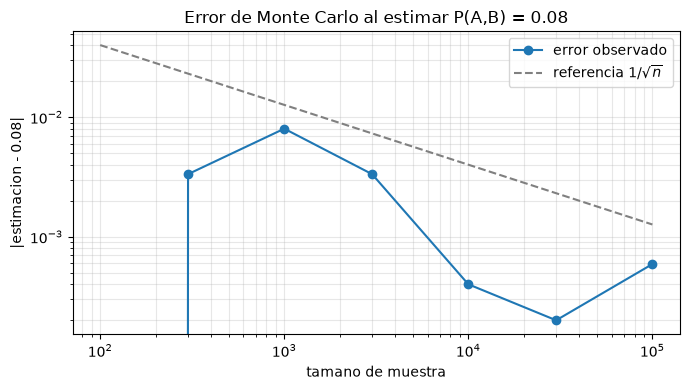

In [38]:
tamanos = [100, 300, 1_000, 3_000, 10_000, 30_000, 100_000]
errores = []
for n in tamanos:
    muestra = muestrear(modelo_factorizado(p_A, p_B_dado_A, p_B_dado_noA), n=n)
    errores.append(abs(p(muestra, {"A": 1, "B": 1})[0] - 0.08))

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(tamanos, errores, "o-", label="error observado")
ax.loglog(tamanos, [0.4 / np.sqrt(n) for n in tamanos], "--",
          color="gray", label=r"referencia $1/\sqrt{n}$")
ax.set_xlabel("tamano de muestra"); ax.set_ylabel("|estimacion - 0.08|")
ax.set_title("Error de Monte Carlo al estimar P(A,B) = 0.08")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

---
# 2. Independencia condicional en grafos

Todo DAG se descompone en tres estructuras básicas. Saber cuál es cuál es la
destreza central de esta unidad:

| Estructura | Grafo | Sin condicionar | Condicionando en $C$ |
|---|---|---|---|
| Cadena causal | $A \to C \to B$ | dependientes | **independientes** |
| Causa común | $A \leftarrow C \to B$ | dependientes | **independientes** |
| Efecto común (colisionador) | $A \to C \leftarrow B$ | **independientes** | dependientes |

El colisionador es el caso contraintuitivo, y es exactamente la condición (1)
del criterio de separación del enunciado: un nodo de aristas convergentes
bloquea el camino **salvo** que él o alguno de sus descendientes esté en $Z$.

## 2.1 Cadena causal $A \to C \to B$

Las CPT se declaran como tensores indexables por el valor del padre:
`cpt([0.2, 0.9])[A]` es $P(C=1 \mid A)$, con 0.2 si $A=0$ y 0.9 si $A=1$.

Los valores teóricos salen de la **ley de probabilidad total**. Por ejemplo:

$$P(B=1 \mid A=1) = \sum_c P(B=1 \mid c)\, P(c \mid A=1) = 0.8 \times 0.9 + 0.1 \times 0.1 = 0.73$$

In [39]:
with pm.Model() as m_cadena:
    A = pm.Bernoulli("A", 0.3)
    C = pm.Bernoulli("C", cpt([0.2, 0.9])[A])     # P(C=1|A)
    pm.Bernoulli("B", cpt([0.1, 0.8])[C])         # P(B=1|C)

mc_cadena = muestrear(m_cadena, n=100_000)
aristas_cadena = [("A", "C"), ("C", "B")]

# Valores teoricos por ley de probabilidad total
teo_C = 0.3 * 0.9 + 0.7 * 0.2                      # P(C=1)
teo_B = teo_C * 0.8 + (1 - teo_C) * 0.1            # P(B=1)

comparar("P(C=1)",     teo_C, p(mc_cadena, {"C": 1}))
comparar("P(B=1)",     teo_B, p(mc_cadena, {"B": 1}))
comparar("P(B=1|A=1)", 0.9 * 0.8 + 0.1 * 0.1, p(mc_cadena, {"B": 1}, {"A": 1}))
comparar("P(B=1|A=0)", 0.2 * 0.8 + 0.8 * 0.1, p(mc_cadena, {"B": 1}, {"A": 0}))

print("\nAl condicionar en C, el valor de A deja de importar (teoria: 0.8):")
comparar("P(B=1|C=1,A=1)", 0.8, p(mc_cadena, {"B": 1}, {"C": 1, "A": 1}))
comparar("P(B=1|C=1,A=0)", 0.8, p(mc_cadena, {"B": 1}, {"C": 1, "A": 0}))

print()
for Z in ([], ["C"]):
    indep, z = independencia_mc(mc_cadena, "A", "B", Z)
    cond = " | C" if Z else "    "
    print(f"  A _|_ B{cond} -> {str(indep):5s} (z = {z:5.1f})   "
          f"d-separados: {d_separado(aristas_cadena, 'A', 'B', Z)}")

Sampling: [A, B, C]


[OK      ] P(C=1)                     teoria  0.4100   MC  0.4096 +/- 0.0031   n=100000   z=  0.3
[OK      ] P(B=1)                     teoria  0.3870   MC  0.3879 +/- 0.0031   n=100000   z=  0.6
[OK      ] P(B=1|A=1)                 teoria  0.7300   MC  0.7308 +/- 0.0051   n= 29990   z=  0.3
[OK      ] P(B=1|A=0)                 teoria  0.2400   MC  0.2410 +/- 0.0032   n= 70010   z=  0.6

Al condicionar en C, el valor de A deja de importar (teoria: 0.8):
[OK      ] P(B=1|C=1,A=1)             teoria  0.8000   MC  0.8026 +/- 0.0049   n= 26938   z=  1.1
[OK      ] P(B=1|C=1,A=0)             teoria  0.8000   MC  0.8016 +/- 0.0067   n= 14019   z=  0.5

  A _|_ B     -> False (z = 119.4)   d-separados: False
  A _|_ B | C -> True  (z =   0.5)   d-separados: True


---
## Ejercicio 3 — Causa común (Figura 1 del enunciado)

Construya el modelo $A \leftarrow C \to B$ con

$$P(C=1) = 0.4, \quad P(A=1 \mid C) = \begin{cases}0.7 & C=1\\ 0.1 & C=0\end{cases},
\quad P(B=1 \mid C) = \begin{cases}0.9 & C=1\\ 0.2 & C=0\end{cases}$$

y verifique que $P(A,B) \neq P(A)P(B)$ pero $P(A,B \mid C) = P(A \mid C)P(B \mid C)$.

**Ojo con el orden de declaración**: en PyMC un nodo sólo puede usar variables
ya definidas, así que $C$ va primero.

In [40]:
with pm.Model() as m_causa:
    # TODO: declare C, luego A y B como hijos de C
    C = pm.Bernoulli("C", 0.5)                  # TODO: P(C=1) = 0.4
    A = pm.Bernoulli("A", 0.5)                  # TODO: use cpt([...])[C]
    B = pm.Bernoulli("B", 0.5)                  # TODO: use cpt([...])[C]

mc_causa = muestrear(m_causa, n=100_000)
aristas_causa = [("C", "A"), ("C", "B")]        # TODO: revise si es correcto

Sampling: [A, B, C]


In [ ]:
# Valores teoricos por ley de probabilidad total
teo_A = 0.4 * 0.7 + 0.6 * 0.1                     # P(A=1)  = 0.34
teo_B = 0.4 * 0.9 + 0.6 * 0.2                     # P(B=1)  = 0.48
teo_AB = 0.4 * 0.7 * 0.9 + 0.6 * 0.1 * 0.2        # P(A,B)  = 0.264

comparar("P(C=1)",     0.40, p(mc_causa, {"C": 1}))
comparar("P(A=1|C=1)", 0.70, p(mc_causa, {"A": 1}, {"C": 1}))
comparar("P(B=1|C=0)", 0.20, p(mc_causa, {"B": 1}, {"C": 0}))
comparar("P(A=1)",   teo_A,  p(mc_causa, {"A": 1}))
comparar("P(A,B)",   teo_AB, p(mc_causa, {"A": 1, "B": 1}))

print(f"\nP(A)P(B) = {teo_A * teo_B:.4f}, pero P(A,B) = {teo_AB:.4f}: dependientes.")
print("Condicionando en C la factorizacion se restablece:")
comparar("P(A,B|C=1)", 0.7 * 0.9, p(mc_causa, {"A": 1, "B": 1}, {"C": 1}))
comparar("P(A,B|C=0)", 0.1 * 0.2, p(mc_causa, {"A": 1, "B": 1}, {"C": 0}))

print()
for Z in ([], ["C"]):
    indep, z = independencia_mc(mc_causa, "A", "B", Z)
    cond = " | C" if Z else "    "
    print(f"  A _|_ B{cond} -> {str(indep):5s} (z = {z:5.1f})   "
          f"d-separados: {d_separado(aristas_causa, 'A', 'B', Z)}")

print()
check("A y B dependientes", not independencia_mc(mc_causa, "A", "B")[0])
check("A y B independientes dado C", independencia_mc(mc_causa, "A", "B", ["C"])[0])

In [ ]:
# Teoria: como A y B son uniformes, P(C=1) es el promedio de la tabla
teo_C = (0.05 + 0.60 + 0.70 + 0.95) / 4                  # 0.575
teo_C_dado_B = (0.60 + 0.95) / 2                         # P(C=1|B=1) = 0.775
teo_B_dado_C = teo_C_dado_B * 0.5 / teo_C                # Bayes -> 0.6739
teo_C_dado_A = (0.70 + 0.95) / 2                         # P(C=1|A=1) = 0.825
teo_B_dado_CA = 0.95 * 0.5 / teo_C_dado_A                # -> 0.5758

comparar("P(C=1)",         teo_C,         p(mc_col, {"C": 1}))
comparar("P(A,B)",         0.25,          p(mc_col, {"A": 1, "B": 1}))
comparar("P(B=1|C=1)",     teo_B_dado_C,  p(mc_col, {"B": 1}, {"C": 1}))
comparar("P(B=1|C=1,A=1)", teo_B_dado_CA, p(mc_col, {"B": 1}, {"C": 1, "A": 1}))

print()
for Z in ([], ["C"], ["D"]):
    indep, z = independencia_mc(mc_col, "A", "B", Z)
    etiqueta = f"A _|_ B{' | ' + Z[0] if Z else '    '}"
    print(f"  {etiqueta:12s} -> {str(indep):5s} (z = {z:5.1f})   "
          f"d-separados: {d_separado(aristas_col, 'A', 'B', Z)}")

print()
check("A y B independientes a priori", independencia_mc(mc_col, "A", "B")[0])
check("A y B dependientes dado C", not independencia_mc(mc_col, "A", "B", ["C"])[0])
check("A y B dependientes dado D (descendiente del colisionador)",
      not independencia_mc(mc_col, "A", "B", ["D"])[0])

print("\nExplaining away: al observar el efecto C, saber que A ocurrio")
print("hace MENOS probable a B, porque A ya 'explica' el efecto.\n")
print(f"  P(B)     = {p(mc_col, {'B': 1})[0]:.4f}")
print(f"  P(B|C)   = {p(mc_col, {'B': 1}, {'C': 1})[0]:.4f}")
print(f"  P(B|C,A) = {p(mc_col, {'B': 1}, {'C': 1, 'A': 1})[0]:.4f}")

---
# 5. Inferencia causal

Hasta aquí todas las probabilidades venían del enunciado. En esta última
sección los números salen de **datos reales**: el registro oficial de
*desvinculación escolar* del Ministerio de Educación de Chile, 2010–2024.

> **Fuente.** Centro de Estudios MINEDUC, *Tasa de incidencia de la
> desvinculación del sistema escolar*, `data/OFICIAL-Tasa-Incidencia-Desvinculacion-2010-2024.xlsx`,
> hoja «Tasas a nivel de Dependencia». La hoja apila tres tablas con el mismo
> formato: total (Tabla 1), mujeres (Tabla 1.a) y hombres (Tabla 1.b).

Un estudiante está **desvinculado** en el año $t$ si estaba matriculado en $t$
y no aparece en la matrícula de $t+1$, sin haber egresado ni fallecido. La
*tasa de incidencia* es esa cuenta dividida por la matrícula teórica.

Trabajaremos con cuatro variables:

| Variable | Valores |
|---|---|
| `Anio` | 2010 … 2024 (15 estados) |
| `Sexo` | Mujer, Hombre |
| `Dep` | Municipal, Particular subvencionado, Particular pagado, C. Adm. delegada, Servicio Local de Educación |
| `D` | 1 = se desvincula, 0 = permanece |

La pregunta que da nombre a la sección **no** es «¿qué tasa tienen los
municipales?» — eso se lee en la tabla. Es:

> ¿Cuál sería la tasa de desvinculación **si** el sistema completo pasara a una
> dependencia dada?

Es decir $P(D = 1 \mid do(\texttt{Dep} = d))$, no $P(D = 1 \mid \texttt{Dep} = d)$.
Son distintas, y la sección trata de cuánto y por qué.

In [ ]:
from pathlib import Path

HOJA = "Tasas a nivel de Dependencia"
DEPS = ["Municipal", "Particular subvencionado", "Particular pagado",
        "C. Adm. delegada", "Servicio Local de educación"]
SEXOS = ["Mujer", "Hombre"]
ANIOS = list(range(2010, 2025))
SIGLAS = {"Municipal": "MUN", "Particular subvencionado": "PSUB",
          "Particular pagado": "PPAG", "C. Adm. delegada": "CAD",
          "Servicio Local de educación": "SLEP"}


def ruta_datos(nombre="OFICIAL-Tasa-Incidencia-Desvinculacion-2010-2024.xlsx"):
    # El notebook vive en labs/pymc_tutorial/; el archivo en data/.
    for base in [Path("."), Path(".."), Path("../.."), Path("../../..")]:
        cand = base / "data" / nombre
        if cand.exists():
            return cand
    raise FileNotFoundError(f"No se encontro data/{nombre}")


def _fila_titulo(hoja, patron):
    col = hoja.iloc[:, 0].astype(str)
    return int(col[col.str.contains(patron, case=False, na=False)].index[0])


def cargar_desvinculacion(ruta=None):
    # Devuelve la tabla en formato largo: una fila por (sexo, dependencia, anio).
    hoja = pd.read_excel(ruta or ruta_datos(), sheet_name=HOJA, header=None)
    # Cada sub-tabla tiene 4 filas de encabezado antes de los datos, y por cada
    # anio un bloque de 6 columnas: Global(desv, matricula, tasa) y luego lo
    # mismo restringido al sistema regular. Nos quedamos con las columnas Global.
    primera = {"Mujer":  _fila_titulo(hoja, r"^Tabla 1\.a") + 4,
               "Hombre": _fila_titulo(hoja, r"^Tabla 1\.b") + 4}
    filas = []
    for sexo, base in primera.items():
        for i, dep in enumerate(DEPS):
            etiqueta = str(hoja.iat[base + i, 0]).split(" /")[0].strip()
            assert etiqueta == dep, f"fila {base + i}: {etiqueta!r} != {dep!r}"
            for j, anio in enumerate(ANIOS):
                c = 1 + 6 * j
                desv, matricula = hoja.iat[base + i, c], hoja.iat[base + i, c + 1]
                if pd.isna(desv) or pd.isna(matricula):
                    continue          # el SLEP no existe antes de 2018
                filas.append({"sexo": sexo, "dep": dep, "anio": int(anio),
                              "desvinculados": int(desv),
                              "matricula": int(matricula)})
    tabla = pd.DataFrame(filas)
    tabla["tasa"] = tabla.desvinculados / tabla.matricula
    return tabla


datos = cargar_desvinculacion()
print(f"{len(datos)} celdas   "
      f"{datos.matricula.sum():,} matriculas   "
      f"{datos.desvinculados.sum():,} desvinculaciones\n")
print(datos.head(3).to_string(index=False))

print("\nTasa por dependencia y anio (%):")
print((100 * datos.pivot_table(index="anio", columns="dep",
                               values="desvinculados", aggfunc="sum")
       / datos.pivot_table(index="anio", columns="dep",
                           values="matricula", aggfunc="sum")).round(2).to_string())

Dos hechos de esa tabla mandan sobre todo lo que sigue:

1. **La tasa cambia mucho por año.** Baja de forma sostenida entre 2011 y 2018,
   se desploma en 2020 (durante la pandemia casi no hubo desvinculación
   registrada) y repunta después.
2. **La composición del sistema también cambia.** La matrícula municipal cae de
   1,25 millones a 0,70 millones, y desde 2018 aparece el **Servicio Local de
   Educación** (SLEP), que absorbe parte de esa matrícula y llega a 395 mil en
   2024.

Es decir: el año afecta a la tasa **y** afecta a la dependencia. Ese es el
patrón de una **causa común**, la estructura de la sección 2.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pivote = (datos.pivot_table(index="anio", columns="dep", values="desvinculados",
                            aggfunc="sum")
          / datos.pivot_table(index="anio", columns="dep", values="matricula",
                              aggfunc="sum"))
for dep in DEPS:
    axes[0].plot(pivote.index, 100 * pivote[dep], "o-", ms=3, label=dep)
axes[0].set_title("Tasa de desvinculacion por dependencia")
axes[0].set_xlabel("anio"); axes[0].set_ylabel("tasa (%)")
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

matricula = datos.pivot_table(index="anio", columns="dep", values="matricula",
                              aggfunc="sum").fillna(0)
axes[1].stackplot(matricula.index, *(matricula[d] / 1e6 for d in DEPS),
                  labels=DEPS, alpha=0.85)
axes[1].set_title("Composicion de la matricula")
axes[1].set_xlabel("anio"); axes[1].set_ylabel("millones de estudiantes")
axes[1].legend(fontsize=7, loc="lower left"); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 5.1 De la tabla al modelo generativo

La tabla da directamente todas las probabilidades condicionales que necesitamos.
Con la matrícula como conteo de la población:

$$P(\texttt{Anio}=a) = \frac{M_{a}}{M}, \qquad
P(\texttt{Sexo}=s \mid a) = \frac{M_{as}}{M_{a}}, \qquad
P(\texttt{Dep}=d \mid a, s) = \frac{M_{asd}}{M_{as}}$$

$$P(D = 1 \mid a, s, d) = \frac{\text{desvinculados}_{asd}}{M_{asd}}$$

donde $M_{asd}$ es la matrícula de la celda. La última es la **tasa de
incidencia** de la tabla: condicionar la desvinculación en sexo, dependencia y
año es exactamente leer una celda.

In [ ]:
nA, nS, nD = len(ANIOS), len(SEXOS), len(DEPS)
idx_anio = {a: i for i, a in enumerate(ANIOS)}
idx_sexo = {s: i for i, s in enumerate(SEXOS)}
idx_dep = {d: i for i, d in enumerate(DEPS)}

MATRICULA = np.zeros((nA, nS, nD))
DESVINC = np.zeros((nA, nS, nD))
for r in datos.itertuples():
    MATRICULA[idx_anio[r.anio], idx_sexo[r.sexo], idx_dep[r.dep]] = r.matricula
    DESVINC[idx_anio[r.anio], idx_sexo[r.sexo], idx_dep[r.dep]] = r.desvinculados

# Celdas que existen. El SLEP tiene matricula 0 antes de 2018: no es una tasa
# baja, es una tasa que no esta definida. Volveremos sobre esto en el Ej. 11.
EXISTE = MATRICULA > 0

TASA = np.divide(DESVINC, MATRICULA, out=np.zeros_like(MATRICULA), where=EXISTE)
P_ANIO = MATRICULA.sum(axis=(1, 2)) / MATRICULA.sum()
P_SEXO = MATRICULA.sum(axis=2) / MATRICULA.sum(axis=2).sum(axis=1, keepdims=True)
P_DEP = MATRICULA / MATRICULA.sum(axis=2, keepdims=True)

print(f"P(Anio) va de {P_ANIO.min():.4f} a {P_ANIO.max():.4f} (casi uniforme)")
print(f"P(Mujer | anio) va de {P_SEXO[:, 0].min():.4f} a {P_SEXO[:, 0].max():.4f}")
print(f"\nP(Dep | anio, Mujer) en 2010 y 2024:")
for anio in (2010, 2024):
    reparto = "  ".join(f"{SIGLAS[d]}={P_DEP[idx_anio[anio], 0, k]:.3f}"
                        for k, d in enumerate(DEPS))
    print(f"  {anio}: {reparto}")

print(f"\nTasa 2024, mujeres municipales: {TASA[idx_anio[2024], 0, 0]:.4f}")
print(f"Tasa 2024, hombres municipales: {TASA[idx_anio[2024], 1, 0]:.4f}")


def muestrear_cat(modelo, n=200_000, semilla=SEMILLA):
    # Igual que muestrear(), pero sin forzar booleanos: aqui Anio, Sexo y Dep
    # tienen mas de dos estados.
    with modelo:
        previa = pm.sample_prior_predictive(draws=n, random_seed=semilla)
    nombres = ([v.name for v in modelo.free_RVs]
               + [d.name for d in modelo.deterministics])
    return pd.DataFrame({v: previa.prior[v].values.reshape(-1) for v in nombres})

---
## Ejercicio 9 — El modelo generativo

Declare en PyMC el modelo que simula **un estudiante** del sistema escolar
chileno 2010–2024:

$$P(a, s, d, D) = P(a)\,P(s \mid a)\,P(d \mid a, s)\,P(D \mid a, s, d)$$

Los cuatro tensores del paso anterior son exactamente esas cuatro CPT. Recuerde
que en PyMC se indexa un tensor con las variables ya declaradas:
`pt.as_tensor(P_SEXO)[Anio]` devuelve el vector de dos probabilidades
correspondiente al año simulado.

**Complete las cuatro líneas.** El orden importa: cada variable sólo puede usar
las anteriores.

In [ ]:
with pm.Model() as m_escolar:
    # TODO: P(Anio) es marginal, no depende de nadie
    Anio = pm.Categorical("Anio", p=pt.as_tensor(np.ones(nA) / nA))

    # TODO: P(Sexo | Anio) -> indexe P_SEXO por Anio
    Sexo = pm.Categorical("Sexo", p=pt.as_tensor(np.ones(nS) / nS))

    # TODO: P(Dep | Anio, Sexo) -> indexe P_DEP por Anio y Sexo
    Dep = pm.Categorical("Dep", p=pt.as_tensor(np.ones(nD) / nD))

    # TODO: P(D=1 | Anio, Sexo, Dep) -> indexe TASA por las tres
    D = pm.Bernoulli("D", 0.5)

mc_escolar = muestrear_cat(m_escolar)
ARISTAS_ESCOLAR = [("Anio", "Sexo"), ("Anio", "Dep"), ("Sexo", "Dep"),
                   ("Anio", "D"), ("Sexo", "D"), ("Dep", "D")]

In [ ]:
# Verificacion: la muestra tiene que reproducir la tabla del MINEDUC.
global_teorico = datos.desvinculados.sum() / datos.matricula.sum()
comparar("P(D=1) global", global_teorico, p(mc_escolar, {"D": 1}))

print()
for k, dep in enumerate(DEPS):
    sub = datos[datos.dep == dep]
    comparar(f"P(D=1 | {dep[:18]})",
             sub.desvinculados.sum() / sub.matricula.sum(),
             p(mc_escolar, {"D": 1}, {"Dep": k}))

print()
for j, sexo in enumerate(SEXOS):
    sub = datos[datos.sexo == sexo]
    comparar(f"P(D=1 | {sexo})",
             sub.desvinculados.sum() / sub.matricula.sum(),
             p(mc_escolar, {"D": 1}, {"Sexo": j}))

print()
celda = datos[(datos.anio == 2024) & (datos.sexo == "Hombre")
              & (datos.dep == "Municipal")]
comparar("P(D=1 | 2024, Hombre, Municipal)", float(celda.tasa.iloc[0]),
         p(mc_escolar, {"D": 1}, {"Anio": idx_anio[2024], "Sexo": 1, "Dep": 0}))

## 5.2 El grafo, y por qué hay confusión

El modelo que acaba de declarar tiene este DAG:

```
        Anio ────────┐
         │  \        │
         │   \       ▼
         │    ──► Dep ──► D
         │        ▲       ▲
         ▼        │       │
        Sexo ─────┴───────┘
```

Para la pregunta «¿qué pasa si intervengo la dependencia?», el camino que
interesa es el directo $\texttt{Dep} \to D$. Pero existe además

$$\texttt{Dep} \leftarrow \texttt{Anio} \to D$$

que es una **causa común** (sección 2.2): el año empuja a la vez la composición
del sistema y la tasa. Ese camino de puerta trasera (*backdoor*) contamina el
contraste observacional. Lo mismo con $\texttt{Dep} \leftarrow \texttt{Sexo} \to D$.

Concretamente: los municipales pesan más en los años **viejos**, que son los de
tasa alta; el SLEP sólo existe en años **recientes**, que son los de tasa baja.
Comparar sus tasas crudas es comparar épocas distintas, no dependencias.

In [ ]:
# El criterio grafico confirma la lectura: hay camino activo entre Dep y D
# aunque no se pase por la arista directa, y {Anio, Sexo} lo bloquea.
sin_directa = [a for a in ARISTAS_ESCOLAR if a != ("Dep", "D")]

print("Camino Dep - D con la arista directa borrada:")
print(f"  sin condicionar        -> activo: "
      f"{camino_activo(sin_directa, 'Dep', 'D')}")
print(f"  condicionando en Anio  -> activo: "
      f"{camino_activo(sin_directa, 'Dep', 'D', ['Anio'])}")
print(f"  condicionando en ambos -> activo: "
      f"{camino_activo(sin_directa, 'Dep', 'D', ['Anio', 'Sexo'])}")

check("{Anio, Sexo} bloquea toda puerta trasera Dep -> D",
      d_separado(sin_directa, "Dep", "D", ["Anio", "Sexo"]),
      "revise ARISTAS_ESCOLAR")

---
## Ejercicio 10 — Ajuste por puerta trasera

Como $\{\texttt{Anio}, \texttt{Sexo}\}$ bloquea todos los caminos de puerta
trasera y ninguno de los dos es descendiente de `Dep`, el conjunto satisface el
**criterio de puerta trasera** y el efecto es identificable:

$$P(D=1 \mid do(\texttt{Dep}=d)) = \sum_{a}\sum_{s} P(D=1 \mid a, s, d)\; P(a, s)$$

Note la diferencia con el condicional observacional, que pesa con
$P(a, s \mid d)$ — la composición **de esa dependencia** — en vez de con
$P(a, s)$ — la composición **del sistema completo**:

$$P(D=1 \mid \texttt{Dep}=d) = \sum_{a}\sum_{s} P(D=1 \mid a, s, d)\; P(a, s \mid d)$$

Las mismas tasas por celda, distintos pesos. Eso es todo lo que hace el
ajuste.

**Complete `tasa_intervenida`**: es la primera fórmula, con `TASA[:, :, k]` como
$P(D=1 \mid a, s, d)$ y `P_CONJUNTA_AS` como $P(a, s)$.

In [ ]:
# P(a, s): la composicion del sistema completo, sin mirar la dependencia.
P_CONJUNTA_AS = MATRICULA.sum(axis=2) / MATRICULA.sum()
print("P(a,s) suma", P_CONJUNTA_AS.sum().round(6), " forma", P_CONJUNTA_AS.shape)


def tasa_cruda(dep):
    # P(D=1 | Dep=dep) leida de la tabla.
    sub = datos[datos.dep == dep]
    return sub.desvinculados.sum() / sub.matricula.sum()

In [ ]:
def tasa_intervenida(dep, anios=None):
    # P(D=1 | do(Dep=dep)), restringido a `anios` si se entrega.
    k = idx_dep[dep]
    filas = [idx_anio[a] for a in (anios if anios is not None else ANIOS)]

    if not EXISTE[np.ix_(filas, range(nS), [k])].all():
        return np.nan          # sin soporte: ver Ejercicio 11

    pesos = P_CONJUNTA_AS[filas]
    pesos = pesos / pesos.sum()

    # TODO: promedie TASA[filas, :, k] con esos pesos
    return np.nan

In [ ]:
# Verificacion: el ajuste analitico contra la simulacion de la intervencion.
# pm.do borra las aristas que entran a Dep y la fija en k: es el grafo mutilado.
print(f"{'dependencia':<30}{'cruda':>9}{'do() formula':>14}{'do() pm.do':>13}")
print("-" * 66)
for k, dep in enumerate(DEPS):
    formula = tasa_intervenida(dep)
    if np.isnan(formula):
        print(f"{dep:<30}{100 * tasa_cruda(dep):8.2f}%{'no definida':>14}"
              f"{'--':>13}")
        continue
    mc_do = muestrear_cat(pm.do(m_escolar, {"Dep": k}), n=100_000)
    print(f"{dep:<30}{100 * tasa_cruda(dep):8.2f}%{100 * formula:13.2f}%"
          f"{100 * mc_do.D.mean():12.2f}%")
    comparar(f"  do({dep[:16]})", formula, p(mc_do, {"D": 1}))

> **Lo que hay que saber leer aquí.** Para las cuatro dependencias que existen
> los quince años, el ajuste **casi no mueve nada** (Municipal 2,05 % → 1,99 %).
> No es un error: significa que la confusión por año y sexo es débil, porque
> $P(a)$ es casi uniforme y la composición por sexo es casi constante. Ajustar
> no siempre cambia la respuesta, y eso también es un resultado.
>
> El SLEP es otra historia, y no porque su confusión sea fuerte.

---
## Ejercicio 11 — Positividad: el caso del SLEP

Leída sin cuidado, la tabla dice que el **Servicio Local de Educación** tiene
una tasa de 1,56 %, contra 2,05 % de los municipales de los que heredó la
matrícula: casi un cuarto menos. Sería un argumento fuerte a favor de la
desmunicipalización.

El problema es que el SLEP **no existe antes de 2018**. Su tasa cruda no es un
promedio sobre 2010–2024: es un promedio sobre 2018–2024, años en que *todas*
las dependencias bajaron. La fórmula de ajuste ni siquiera está definida, porque
exige $P(\texttt{Dep} = \text{SLEP} \mid a, s) > 0$ para todo $(a,s)$ — la
condición de **positividad** o soporte común. Por eso `tasa_intervenida`
devuelve `nan`.

La única comparación honesta es sobre el soporte común.

**(a)** Complete `ANIOS_SLEP` con los años en que el SLEP tiene matrícula.
**(b)** Compare las cinco dependencias **sobre esos años**, y responda si
sobrevive la ventaja del SLEP.

In [ ]:
# TODO (a): los anios donde EXISTE es verdadero para el SLEP (en ambos sexos)
ANIOS_SLEP = ANIOS

print(f"El SLEP tiene matricula en {len(ANIOS_SLEP)} de {len(ANIOS)} anios: "
      f"{ANIOS_SLEP}")

In [ ]:
# (b) La misma comparacion, sobre todos los anios y sobre el soporte comun.
print(f"{'dependencia':<30}{'cruda 2010-24':>15}{'do() 2010-24':>14}"
      f"{'do() soporte':>14}")
print("-" * 73)
for dep in DEPS:
    completo = tasa_intervenida(dep)
    comun = tasa_intervenida(dep, ANIOS_SLEP)
    txt = f"{100 * completo:13.2f}%" if not np.isnan(completo) else f"{'no def.':>14}"
    print(f"{dep:<30}{100 * tasa_cruda(dep):14.2f}%{txt}{100 * comun:13.2f}%")

slep = tasa_intervenida("Servicio Local de educación", ANIOS_SLEP)
muni = tasa_intervenida("Municipal", ANIOS_SLEP)
print(f"\nVentaja cruda del SLEP sobre Municipal (2010-2024): "
      f"{100 * (tasa_cruda('Municipal') - tasa_cruda('Servicio Local de educación')):+.2f} pp")
print(f"Ventaja sobre el soporte comun (2018-2024):        "
      f"{100 * (muni - slep):+.2f} pp")

check("la ventaja cruda del SLEP supera 0.4 pp",
      tasa_cruda("Municipal") - tasa_cruda("Servicio Local de educación") > 0.004)
check("sobre el soporte comun la diferencia es menor a 0.1 pp",
      abs(muni - slep) < 0.001,
      "compare TASA[.., SLEP] contra TASA[.., Municipal] anio por anio")

La ventaja desaparece por completo: sobre 2018–2024 el SLEP y los municipales
desvinculan a la misma tasa, dentro de una centésima de punto porcentual. Los
0,49 puntos de diferencia eran **la ventana temporal**, no la dependencia.

Es el mismo mecanismo de la sección 2.2 — la causa común `Anio` — pero con una
vuelta de tuerca: aquí no bastaba con ajustar, porque para la mitad de los años
la pregunta «¿cuál habría sido la tasa del SLEP?» no tiene respuesta en los
datos. Ninguna fórmula de ajuste inventa soporte que no existe; lo único
correcto es reducir la pregunta a donde sí lo hay.

> **Dos advertencias sobre lo que *no* se puede concluir.**
>
> 1. **`Sexo` no admite `do()`.** El contraste hombres 1,77 % / mujeres 1,48 %
>    es real y sobrevive al ajuste por año y dependencia, pero no hay
>    intervención que asigne el sexo de un estudiante. Es una diferencia
>    descriptiva entre grupos, no un efecto causal: *no hay causación sin
>    manipulación*.
> 2. **Son datos agregados.** La tabla entrega celdas, no estudiantes. Un
>    contraste válido entre celdas puede no valer para individuos — la
>    **falacia ecológica**. Además `Dep` no se asigna al azar: las familias
>    eligen colegio, y el nivel socioeconómico, que no está en esta tabla,
>    empuja a la vez la elección y la desvinculación. Ese confusor no medido
>    **no** lo arregla ningún ajuste sobre las variables disponibles, así que la
>    columna `do()` de arriba vale bajo el supuesto — fuerte — de que el DAG de
>    la sección 5.2 está completo.